In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [9]:
df = pd.read_csv("tissue_dataset.csv")
X = df.drop(columns = ["target", "target_actual"])
y = df["target"]
top25_miRNA = pd.read_csv("results/optimal_25_miRNA_panel.csv")
selected_features = top25_miRNA["miRNA"].tolist()
X_optimal = X[selected_features]
X_optimal.shape

(133, 25)

In [15]:
#Classification using SVM
pipeline = Pipeline([
    (
        "smote",
        SMOTE(random_state = 42)
    ),
    (
        "svm",
        SVC(
            kernel = "linear",
            probability = True,
            random_state = 42
        )
    )
])
cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)
scores = cross_validate(
    pipeline,
    X_optimal,
    y,
    cv = cv,
     scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }
)

validation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Mean": [
        scores["test_accuracy"].mean(),
        scores["test_precision"].mean(),
        scores["test_recall"].mean(),
        scores["test_f1"].mean(),
        scores["test_roc_auc"].mean()
    ],
    "Std": [
        scores["test_accuracy"].std(),
        scores["test_precision"].std(),
        scores["test_recall"].std(),
        scores["test_f1"].std(),
        scores["test_roc_auc"].std()
    ]
})

validation_results.to_csv(
    "results/validation_results.csv",
    index=False
)
validation_results

,Metric,Mean,Std
0,Accuracy,0.992308,0.015385
1,Precision,0.992000,0.016000
2,Recall,1.000000,0.000000
3,F1 Score,0.995918,0.008163
4,ROC-AUC,0.991667,0.016667


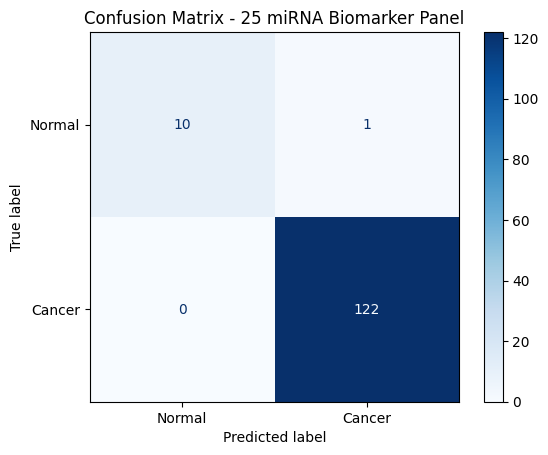

In [21]:
#Confusion Matrix
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_pred = cross_val_predict(
    pipeline,
    X_optimal,
    y,
    cv=cv
)
cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Cancer"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - 25 miRNA Biomarker Panel")
plt.savefig(
    "figures/Confusion_Matrix",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Final Biomarker Panel Validation

The optimal 25-miRNA biomarker panel identified through mRMR and Incremental Feature Selection (IFS) was evaluated using a linear SVM classifier with SMOTE and 5-fold stratified cross-validation.

The panel achieved excellent classification performance with a mean Accuracy of **0.9923**, Precision of **0.9920**, Recall of **1.0000**, F1 Score of **0.9959**, and ROC-AUC of **0.9917**. The low standard deviations across folds indicate stable and consistent performance.

Notably, the model achieved perfect sensitivity (Recall = 1.0), demonstrating its ability to correctly identify all cancer samples. These results validate the effectiveness of the proposed 25-miRNA biomarker panel for distinguishing cancer and normal tissue samples.

Furthermore, hsa-miR-3185 and hsa-miR-4785 emerged as the most robust candidate biomarkers, as they were consistently identified by all five feature ranking methods and retained within the final validated biomarker panel.
